In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)

plt.style.use('dark_background')

# Read and clean data

In [2]:
data_folder = 'C:/Users/Graham West/Python Notebooks/Meharry Teaching/Datasets/'

df = pd.read_csv(data_folder + 'Real Estate/Real Estate Data.csv', index_col=0, header=0)
df = df.reset_index(drop=True)

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1404 entries, 0 to 1403
Data columns (total 68 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Type                      1404 non-null   object 
 1   Zoning Class              1404 non-null   object 
 2   Lot Frontage              1151 non-null   float64
 3   Lot Area                  1404 non-null   int64  
 4   Alley                     84 non-null     object 
 5   Lot Shape                 1404 non-null   object 
 6   Land Contour              1404 non-null   object 
 7   Lot Config                1404 non-null   object 
 8   Land Slope                1404 non-null   object 
 9   Nbhd                      1404 non-null   object 
 10  Location Condition        1404 non-null   object 
 11  Bldg Type                 1404 non-null   object 
 12  House Style               1404 non-null   object 
 13  OvQual                    1404 non-null   int64  
 14  Overall 

,Type,Zoning Class,Lot Frontage,Lot Area,Alley,Lot Shape,Land Contour,Lot Config,Land Slope,Nbhd,Location Condition,Bldg Type,House Style,OvQual,Overall Cond,Built,Year Remod Add,Roof Style,Roof Material,Exterior Primary,Masonry/Veneer,Masonry/Veneer Area,Exterior Qual,Exterior Cond,Foundation,Basement Height,Basement Cond,Basement Exposure,Basement Finish,Basement Finished Area,Basement Unfinished Area,Basement Area,Heating Qual,CentralAir,Electrical,1st Floor Area,2nd Floor Area,Living Area Above Grade,Basement Full Baths,Basement Half baths,Full Baths Above Grade,Half Baths Above Grade,Bedrooms Above Grade,Kitchens Above Grade,Kitchen Qual,Total Rooms Above Grade,Functionality,Fireplaces,Fireplce Qual,Garage Type,Garage Yr Built,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck Area,Open Porch Area,Enclosed Porch Area,3 Season Porch Area,Screen Porch Area,Pool Area,Pool Qual,Fence,Sale Type,Sale Condition,Sale Price
0,2-STORY 1946 & NEWER,Resid Low Density,65.0,8450,NaN,Regular,Level,Inside lot,Gentle,College Creek,Normal,1-family Detached,2 story,7,5,2003,2003,Gable,Composite Shingle,Vinyl Siding,Brick Face,196.0,Good,Average,Poured Contrete,"Good (90-99"")",Average,No Exposure,Good Living Quarters,706,150,856,Excellent,Y,Standard Circuit Breakers & Romex,856,854,1710,1,0,2,1,3,1,Good,8,Typical Functionality,0,No Fireplace,Attached to home,2003.0,Rough Finished,2,548,Average,Average,Paved,0,61,0,0,0,0,No Pool,No Fence,Warranty Deed - Conventional,Normal Sale,208500
1,1-STORY 1946 & NEWER,Resid Low Density,80.0,9600,NaN,Regular,Level,Frontage on 2 sides,Gentle,Veenker,Adjacent Feeder St,1-family Detached,1 story,6,8,1976,1976,Gable,Composite Shingle,Metal Siding,NaN,0.0,Average,Average,Cinder Block,"Good (90-99"")",Average,Good Exposure,Avg Living Quarters,978,284,1262,Excellent,Y,Standard Circuit Breakers & Romex,1262,0,1262,0,1,2,0,3,1,Average,6,Typical Functionality,1,Average,Attached to home,1976.0,Rough Finished,2,460,Average,Average,Paved,298,0,0,0,0,0,No Pool,No Fence,Warranty Deed - Conventional,Normal Sale,181500
2,2-STORY 1946 & NEWER,Resid Low Density,68.0,11250,NaN,Slightly irregular,Level,Inside lot,Gentle,College Creek,Normal,1-family Detached,2 story,7,5,2001,2002,Gable,Composite Shingle,Vinyl Siding,Brick Face,162.0,Good,Average,Poured Contrete,"Good (90-99"")",Average,Min Exposure,Good Living Quarters,486,434,920,Excellent,Y,Standard Circuit Breakers & Romex,920,866,1786,1,0,2,1,3,1,Good,6,Typical Functionality,1,Average,Attached to home,2001.0,Rough Finished,2,608,Average,Average,Paved,0,42,0,0,0,0,No Pool,No Fence,Warranty Deed - Conventional,Normal Sale,223500
3,2-STORY 1945 & OLDER,Resid Low Density,60.0,9550,NaN,Slightly irregular,Level,Corner lot,Gentle,Crawford,Normal,1-family Detached,2 story,7,5,1915,1970,Gable,Composite Shingle,Wood Siding,NaN,0.0,Average,Average,Brick & Tile,"Typical (80-89"")",Good,No Exposure,Avg Living Quarters,216,540,756,Good,Y,Standard Circuit Breakers & Romex,961,756,1717,1,0,1,0,3,1,Good,7,Typical Functionality,1,Good,Detached from home,1998.0,Unfinished,3,642,Average,Average,Paved,0,35,272,0,0,0,No Pool,No Fence,Warranty Deed - Conventional,"Abnormal Sale - trade, foreclosure, short sale",140000
4,2-STORY 1946 & NEWER,Resid Low Density,84.0,14260,NaN,Slightly irregular,Level,Frontage on 2 sides,Gentle,Northridge,Normal,1-family Detached,2 story,8,5,2000,2000,Gable,Composite Shingle,Vinyl Siding,Brick Face,350.0,Good,Average,Poured Contrete,"Good (90-99"")",Average,Avg Exposure,Good Living Quarters,655,490,1145,Excellent,Y,Standard Circuit Breakers & Romex,1145,1053,2198,1,0,2,1,4,1,Good,9,Typical Functionality,1,Average,Attached to home,2000.0,Rough Finished,3,836,Average,Average,Paved,192,84,0,0,0,0,No Pool,No Fence,Warranty Deed - Conventional,Normal Sale,250000


### Rename columns

In [3]:
df = df.rename(columns = {'OvQual':'Overall Qual',
                          'Built':'Year',
                          'Garage Yr Built':'Year Garage'})

### Drop Alley column

In [4]:
df = df.drop(columns=['Alley'])

### Fill nans

In [5]:
df.isna().sum(axis=0).sort_values(ascending=False)

Masonry/Veneer              824
Lot Frontage                253
Year Garage                  63
Masonry/Veneer Area           8
Total Rooms Above Grade       0
Garage Type                   0
Fireplce Qual                 0
Fireplaces                    0
Functionality                 0
Type                          0
Garage Finish                 0
Kitchens Above Grade          0
Bedrooms Above Grade          0
Half Baths Above Grade        0
Full Baths Above Grade        0
Basement Half baths           0
Basement Full Baths           0
Kitchen Qual                  0
Garage Cars                   0
2nd Floor Area                0
Garage Area                   0
Garage Qual                   0
Garage Cond                   0
Paved Drive                   0
Wood Deck Area                0
Open Porch Area               0
Enclosed Porch Area           0
3 Season Porch Area           0
Screen Porch Area             0
Pool Area                     0
Pool Qual                     0
Fence   

In [6]:
gb1 = df.groupby(["Nbhd"])['Lot Frontage'].median().sort_values()

def fill_1(r):
    n = r.Nbhd
    
    x = r['Lot Frontage']
    
    if pd.isna(x):
        return gb1[n]
    else:
        return x
    # end
# end

df['Lot Frontage'] = df.apply(fill_1, axis=1)

In [7]:
gb2 = df.groupby(["Nbhd"])['Year Garage'].median().sort_values()

def fill_2(r):
    n = r.Nbhd
    
    x = r['Year Garage']
    
    if pd.isna(x):
        return gb2[n]
    else:
        return x
    # end
# end

df['Year Garage'] = df.apply(fill_2, axis=1)

In [8]:
gb3 = df.groupby(["Nbhd"])['Masonry/Veneer Area'].median().sort_values()

def fill_3(r):
    n = r.Nbhd
    
    x = r['Masonry/Veneer Area']
    
    if pd.isna(x):
        return gb2[n]
    else:
        return x
    # end
# end

df['Masonry/Veneer Area'] = df.apply(fill_3, axis=1)

In [9]:
df.isna().sum(axis=0).sort_values(ascending=False)

Masonry/Veneer              824
Type                          0
Kitchen Qual                  0
Garage Type                   0
Fireplce Qual                 0
Fireplaces                    0
Functionality                 0
Total Rooms Above Grade       0
Kitchens Above Grade          0
1st Floor Area                0
Bedrooms Above Grade          0
Half Baths Above Grade        0
Full Baths Above Grade        0
Basement Half baths           0
Basement Full Baths           0
Living Area Above Grade       0
Year Garage                   0
Garage Finish                 0
Garage Cars                   0
Garage Area                   0
Garage Qual                   0
Garage Cond                   0
Paved Drive                   0
Wood Deck Area                0
Open Porch Area               0
Enclosed Porch Area           0
3 Season Porch Area           0
Screen Porch Area             0
Pool Area                     0
Pool Qual                     0
Fence                         0
Sale Typ

### Drop Masonry/Veneer column

In [10]:
df = df.drop(columns=['Masonry/Veneer'])

# Feature engineering

### Floors

In [11]:
def get_floors(x):
    if x > 0:
        return 2
    else:
        return 1
    # end
# end

df['Floors'] = df['2nd Floor Area'].apply(get_floors)

### Areas

In [12]:
df['Indoor Area'] = df[
    [
        '1st Floor Area', '2nd Floor Area', 'Basement Area'
    ]
].sum(axis=1)

df['Outdoor Area'] = df[
    [
        '3 Season Porch Area', 'Enclosed Porch Area', 'Garage Area',
        'Open Porch Area', 'Pool Area', 'Screen Porch Area', 'Wood Deck Area'
    ]
].sum(axis=1)

df['Basement Finished Area Fraction'] = df['Basement Finished Area'] / df[['Basement Finished Area', 'Basement Unfinished Area']].sum(axis=1)
df['Basement Finished Area Fraction'] = df['Basement Finished Area Fraction'].fillna(0)

In [13]:
df = df.drop(
    columns=[
       '1st Floor Area', '2nd Floor Area', '3 Season Porch Area',
       'Basement Area', 'Basement Finished Area', 'Basement Unfinished Area',
       'Enclosed Porch Area', 'Garage Area', 'Living Area Above Grade',
       'Open Porch Area', 'Pool Area', 'Screen Porch Area', 'Wood Deck Area'
    ]
)

### Label encode qualities

In [14]:
from sklearn.preprocessing import OrdinalEncoder

# Define known categories
quality_order = ["Poor", "Fair", "Average", "Good", "Excellent"]

# Identify categorical columns that contain 'Average'
cols = df.columns[df.isin(['Average']).any(axis=0)]

# Replace unknown values with "Poor"
df[cols] = df[cols].applymap(lambda x: x if x in quality_order else "Poor")

# Initialize and fit OrdinalEncoder on a single-column DataFrame
encoder = OrdinalEncoder(
    categories=[quality_order]
)

encoder.fit(
    np.array(quality_order)[:,np.newaxis]
)

# Transform each column separately in a loop
for c in cols:
    df[c] = encoder.transform(df[[c]]).astype(int)[:,0]
# end

In [15]:
df['Basement Height'] = df['Basement Height'].apply(
    lambda x: x.split(" ")[0]
)

df['Basement Height'] = df['Basement Height'].apply(
    lambda x: x if x != "Typical" else "Average"
)

df['Basement Height'] = df['Basement Height'].apply(
    lambda x: x if x in quality_order else "Poor"
)

df['Basement Height'] = encoder.transform(df[['Basement Height']]).astype(int)[:,0]

In [16]:
df['Pool Qual'] = df['Pool Qual'].apply(
    lambda x: x if x in quality_order else "Poor"
)

df['Pool Qual'] = encoder.transform(df[['Pool Qual']]).astype(int)[:,0]

### Central Air

In [17]:
df['CentralAir'] = df['CentralAir'].replace(
    {
        'Y':1,
        'N':0
    }
)

df = df.rename(
    columns={
        'CentralAir':'Central Air'
    }
)

# Preprocess data

In [18]:
df.sample(5)

,Type,Zoning Class,Lot Frontage,Lot Area,Lot Shape,Land Contour,Lot Config,Land Slope,Nbhd,Location Condition,Bldg Type,House Style,Overall Qual,Overall Cond,Year,Year Remod Add,Roof Style,Roof Material,Exterior Primary,Masonry/Veneer Area,Exterior Qual,Exterior Cond,Foundation,Basement Height,Basement Cond,Basement Exposure,Basement Finish,Heating Qual,Central Air,Electrical,Basement Full Baths,Basement Half baths,Full Baths Above Grade,Half Baths Above Grade,Bedrooms Above Grade,Kitchens Above Grade,Kitchen Qual,Total Rooms Above Grade,Functionality,Fireplaces,Fireplce Qual,Garage Type,Year Garage,Garage Finish,Garage Cars,Garage Qual,Garage Cond,Paved Drive,Pool Qual,Fence,Sale Type,Sale Condition,Sale Price,Floors,Indoor Area,Outdoor Area,Basement Finished Area Fraction
494,SPLIT OR MULTI-LEVEL,Resid Low Density,80.0,10448,Slightly irregular,Level,Corner lot,Gentle,Northwest Ames,Normal,1-family Detached,Split Level,6,6,1972,1972,Gable,Composite Shingle,Hard Board,333.0,2,2,Cinder Block,2,2,No Exposure,Unfinshed,2,1,Standard Circuit Breakers & Romex,0,0,2,1,3,1,2,7,Typical Functionality,1,2,Attached to home,1972.0,Rough Finished,2,2,2,Paved,0,Good Privacy,Court Officer Deed/Estate,"Abnormal Sale - trade, foreclosure, short sale",158000,2,2808,687,0.000000
691,1-STORY 1946 & NEWER,Resid Low Density,70.0,8120,Regular,Level,Inside lot,Gentle,North Ames,Normal,1-family Detached,1 story,4,7,1970,1970,Gable,Composite Shingle,Metal Siding,0.0,2,3,Cinder Block,2,2,No Exposure,Avg Living Quarters,4,1,Standard Circuit Breakers & Romex,0,0,1,0,3,1,2,5,Typical Functionality,0,0,Detached from home,1994.0,Unfinished,2,2,2,Paved,0,No Fence,Warranty Deed - Conventional,Normal Sale,124500,1,1728,463,0.221065
1384,1-STORY 1946 & NEWER,Resid Low Density,96.0,12444,Regular,Level,Frontage on 2 sides,Gentle,Northridge Heights,Normal,1-family Detached,1 story,8,5,2008,2008,Hip,Composite Shingle,Vinyl Siding,426.0,4,2,Poured Contrete,4,2,Avg Exposure,Good Living Quarters,4,1,Standard Circuit Breakers & Romex,1,0,2,0,2,1,4,7,Typical Functionality,1,3,Attached to home,2008.0,Finished,3,2,2,Paved,0,No Fence,Home just constructed and sold,Home was not completed when last assessed (ass...,394617,1,3864,1144,0.691511
985,1-STORY 1946 & NEWER,Resid Low Density,85.0,15498,Slightly irregular,Level,Corner lot,Gentle,Timberland,Normal,1-family Detached,1 story,8,6,1976,1976,Hip,Wood Shakes,Stone,0.0,3,2,Cinder Block,3,2,Avg Exposure,Avg Living Quarters,2,1,Standard Circuit Breakers & Romex,1,0,2,0,2,1,3,10,Typical Functionality,1,3,Attached to home,1976.0,Finished,2,2,2,Paved,0,No Fence,Court Officer Deed/Estate,"Abnormal Sale - trade, foreclosure, short sale",287000,1,4463,911,1.000000
544,1-STORY 1946 & NEWER,Resid Low Density,70.0,10171,Slightly irregular,Level,Inside lot,Gentle,Northridge Heights,Normal,1-family Detached,1 story,7,5,2004,2004,Gable,Composite Shingle,Vinyl Siding,168.0,3,2,Poured Contrete,3,2,No Exposure,Good Living Quarters,4,1,Standard Circuit Breakers & Romex,0,0,2,0,3,1,3,7,Typical Functionality,0,0,Attached to home,2004.0,Rough Finished,2,2,2,Paved,0,No Fence,Warranty Deed - Conventional,Normal Sale,214000,1,3052,532,0.001318


In [19]:
label = 'Overall Qual'

df = df[ df['Overall Qual']!=1 ].reset_index(drop=True)

X_raw = df.drop(columns=[label])
y = df[label].copy()

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(y)
y = le.transform(y)

y = pd.Series(y)
y.value_counts().sort_index()

0      2
1     15
2    102
3    380
4    359
5    316
6    167
7     43
8     18
Name: count, dtype: int64

### Split numeric and categorical columns for separate processing

In [20]:
X_num = X_raw.select_dtypes(exclude=object)
X_cat = X_raw.select_dtypes(include=object)

### Process numerical data in several ways

In [21]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()

X_num_ss = pd.DataFrame()
for c in X_num.columns:
    X_num_ss[c] = std_scaler.fit_transform(X_num[[c]])[:,0]
# end

### Get categorical dummies

In [22]:
X_dum = pd.DataFrame()
for c in X_cat.columns:
    dummy = pd.get_dummies(X_cat[c], prefix=c, dtype=int)
    dummy_sum = dummy.sum(axis=0)
    col_to_drop = dummy_sum.idxmax()
    dummy = dummy.drop(columns=[col_to_drop])
    X_dum = pd.concat([X_dum, dummy], axis=1)
# end
X_dum.head()

,Type_1 STORY PUD,Type_1-1/2 STORY ALL AGES,Type_1-STORY 1945 & OLDER,Type_1-STORY PUD,Type_2 FAMILY CONVERSION,Type_2-1/2 STORY ALL AGES,Type_2-STORY 1945 & OLDER,Type_2-STORY 1946 & NEWER,Type_2-STORY PUD,Type_DUPLEX,Type_SPLIT FOYER,Type_SPLIT OR MULTI-LEVEL,Zoning Class_Commercial,Zoning Class_Floating Village Resid,Zoning Class_Resid High Density,Zoning Class_Resid Med Density,Lot Shape_Irregular,Lot Shape_Slightly irregular,Land Contour_Banked,Land Contour_Depression,Land Contour_Hillside,Lot Config_Corner lot,Lot Config_Cul-de-sac,Lot Config_Frontage on 2 sides,Lot Config_Frontage on 3 sides,Land Slope_Moderate,Land Slope_Severe,Nbhd_Bloomington Heights,Nbhd_Bloomington Hts,Nbhd_Bluestem,Nbhd_Briardale,Nbhd_Brookside,Nbhd_Clear Creek,Nbhd_College Creek,Nbhd_Crawford,Nbhd_Edwards,Nbhd_Gilbert,Nbhd_Iowa DOT and Rail Road,Nbhd_Meadow Village,Nbhd_Mitchell,Nbhd_Northpark Villa,Nbhd_Northridge,Nbhd_Northridge Heights,Nbhd_Northwest Ames,Nbhd_Old Town,Nbhd_Sawyer,Nbhd_Sawyer West,Nbhd_Somerset,Nbhd_South & West of Iowa State,Nbhd_Stone Brook,...,Exterior Primary_Stucco,Exterior Primary_Wood Shingles,Exterior Primary_Wood Siding,Foundation_Brick & Tile,Foundation_Cinder Block,Foundation_Slab,Foundation_Stone,Foundation_Wood,Basement Exposure_Avg Exposure,Basement Exposure_Good Exposure,Basement Exposure_Min Exposure,Basement Exposure_No Basement,Basement Finish_Avg Living Quarters,Basement Finish_Avg Rec Room,Basement Finish_Below Avg Living Quarters,Basement Finish_Low Quality,Basement Finish_No Basement,Basement Finish_Unfinshed,Electrical_60 AMP Fuse Box and mostly Romex wiring (Fair),Electrical_Fuse Box over 60 AMP and all Romex wiring (Average),Functionality_Major Deductions 1,Functionality_Minor Deductions 1,Functionality_Minor Deductions 2,Functionality_Moderate Deductions,Garage Type_Basement Garage,Garage Type_Built-In (Garage with Room),Garage Type_Car Port,Garage Type_Detached from home,Garage Type_More than one type of garage,Garage Type_No Garage,Garage Finish_Finished,Garage Finish_No Garage,Garage Finish_Rough Finished,Paved Drive_Dirt/Gravel,Paved Drive_Partial Pavement,Fence_Good Privacy,Fence_Good Wood,Fence_Minimum Privacy,Fence_Minimum Wood/Wire,Sale Type_Contract 15% Down payment regular terms,Sale Type_Contract Low Down,Sale Type_Contract Low Down payment and low interest,Sale Type_Contract Low Interest,Sale Type_Court Officer Deed/Estate,Sale Type_Home just constructed and sold,Sale Type_Warranty Deed - Cash,"Sale Condition_Abnormal Sale - trade, foreclosure, short sale","Sale Condition_Allocation - two linked properties with separate deeds, typically condo with a garage unit",Sale Condition_Home was not completed when last assessed (associated with New Homes),Sale Condition_Sale between family members
0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
4,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


# Modeling

In [23]:
X = pd.concat([X_num_ss, X_dum], axis=1)

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y
)

## Parsimony (remove excess features)

In [25]:
from sklearn.ensemble import GradientBoostingClassifier

# Fit a Random Forest model
gb = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1, max_leaf_nodes=10
)
gb.fit(X_test, y_test)

# Get feature importances
importances = pd.Series(
    gb.feature_importances_, index=X.columns
).sort_values(ascending=False)

importances = importances[:100]

features_gb = importances.index

X_pars = X[ features_gb ]
importances

Sale Price                                                                                                   0.293131
Year                                                                                                         0.098373
Lot Area                                                                                                     0.054811
Outdoor Area                                                                                                 0.048990
Indoor Area                                                                                                  0.038749
Year Remod Add                                                                                               0.037652
Masonry/Veneer Area                                                                                          0.030145
Lot Frontage                                                                                                 0.028820
Year Garage                                             

### Variance Inflation Factor

In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X_pars_with_const = sm.add_constant(X_pars)

vif = pd.Series(
    [variance_inflation_factor(X_pars_with_const.values, i) for i in range(X_pars_with_const.shape[1])],
    index=X_pars_with_const.columns
).sort_values(ascending=False)

vif[:10]

Type_DUPLEX                                                                                   inf
Bldg Type_Duplex                                                                              inf
Sale Type_Home just constructed and sold                                                43.753665
Sale Condition_Home was not completed when last assessed (associated with New Homes)    43.617267
const                                                                                   34.843428
House Style_2 story                                                                     26.381010
House Style_Split Level                                                                 23.104965
Type_SPLIT OR MULTI-LEVEL                                                               22.653305
Floors                                                                                  21.047751
House Style_1.5 story: 2nd level fin                                                    18.410110
dtype: float64

In [27]:
# Copy dataset to avoid modifying the original
X_vif = X_pars.copy()

# Iteratively remove features with high VIF
while True:
    # Add constant for intercept
    X_vif_with_const = sm.add_constant(X_vif)
    
    # Compute VIF for all features
    vif_series = pd.Series(
        [variance_inflation_factor(X_vif_with_const.values, i) for i in range(X_vif_with_const.shape[1])],
        index=X_vif_with_const.columns
    )
    
    # Exclude constant term and get the feature with the highest VIF
    vif_series = vif_series.drop('const', errors='ignore')
    highest_vif_feature = vif_series.idxmax()
    #display(vif_series)
    
    # Break the loop if all features have VIF ≤ 10
    if vif_series.loc[highest_vif_feature] <= 10:  # Checking the first feature after 'const'
        break

    # Drop the feature with the highest VIF
    X_vif = X_vif.drop(columns=[highest_vif_feature])

    print(f"Dropped: {highest_vif_feature} (VIF={vif_series.loc[highest_vif_feature]:.2f})")
# end

vif_series.sort_values(ascending=False)[:10]

Dropped: Bldg Type_Duplex (VIF=inf)
Dropped: Sale Type_Home just constructed and sold (VIF=43.75)
Dropped: House Style_2 story (VIF=26.38)
Dropped: Type_SPLIT OR MULTI-LEVEL (VIF=22.33)
Dropped: Type_1-1/2 STORY ALL AGES (VIF=13.10)
Dropped: Year (VIF=10.60)


Floors                                 8.268899
Sale Price                             6.109454
Type_2-STORY 1946 & NEWER              6.090342
Indoor Area                            5.602697
House Style_Split Foyer                4.827289
Nbhd_Somerset                          4.827049
Total Rooms Above Grade                4.740122
Zoning Class_Floating Village Resid    4.449889
Type_2-1/2 STORY ALL AGES              4.439149
Type_SPLIT FOYER                       4.338192
dtype: float64

## Keras

### Create model

In [28]:
from keras.models import Sequential
from keras.layers import *

dropout_rate = 0.25
n_classes = y.nunique()

# Create model
model = Sequential([
    Input(shape=X_train.shape[1:]),
    
    Dense(20),
    BatchNormalization(),
    Activation('relu'),
    Dropout(dropout_rate),

    Dense(20),
    BatchNormalization(),
    Activation('relu'),
    Dropout(dropout_rate),
    
    Dense(10, activation='relu'),
    
    Dense(n_classes, activation='softmax'),
])

# Display model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │         3,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20)             │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20)             │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,389 (17.14 KB)

 Trainable params: 4,309 (16.83 KB)

 Non-trainable params: 80 (320.00 B)

### Compile model

In [29]:
from tensorflow.keras.optimizers import Adam

# define training parameters
epochs     = 500
batch_size = 256

# Define the optimizer with a custom learning rate
initial_learning_rate = 0.05

optimizer = Adam(
    learning_rate=initial_learning_rate,
)

# Compile model
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Add early stopping and learning rate reduction callbacks

In [30]:
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=50,          # Stop after 5 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

### Train model

In [31]:
# Train model
history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    validation_data=(X_test, y_test),
    verbose=1,
    callbacks=[
        early_stopping,
    ]
)

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.2412 - loss: 2.0717 - val_accuracy: 0.4413 - val_loss: 1.7377
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4372 - loss: 1.4854 - val_accuracy: 0.4520 - val_loss: 1.5405
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4768 - loss: 1.3326 - val_accuracy: 0.4448 - val_loss: 1.9457
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4959 - loss: 1.2503 - val_accuracy: 0.4342 - val_loss: 1.5626
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5135 - loss: 1.1650 - val_accuracy: 0.4555 - val_loss: 1.6753
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5213 - loss: 1.1366 - val_accuracy: 0.3808 - val_loss: 1.5111
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5502 - loss: 1.1142 - val_accuracy: 0.3950 - val_loss: 1.4807
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5419 - loss: 1.0468 - val_accuracy: 0.4199 - val_loss:

### Evaluate model performance

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


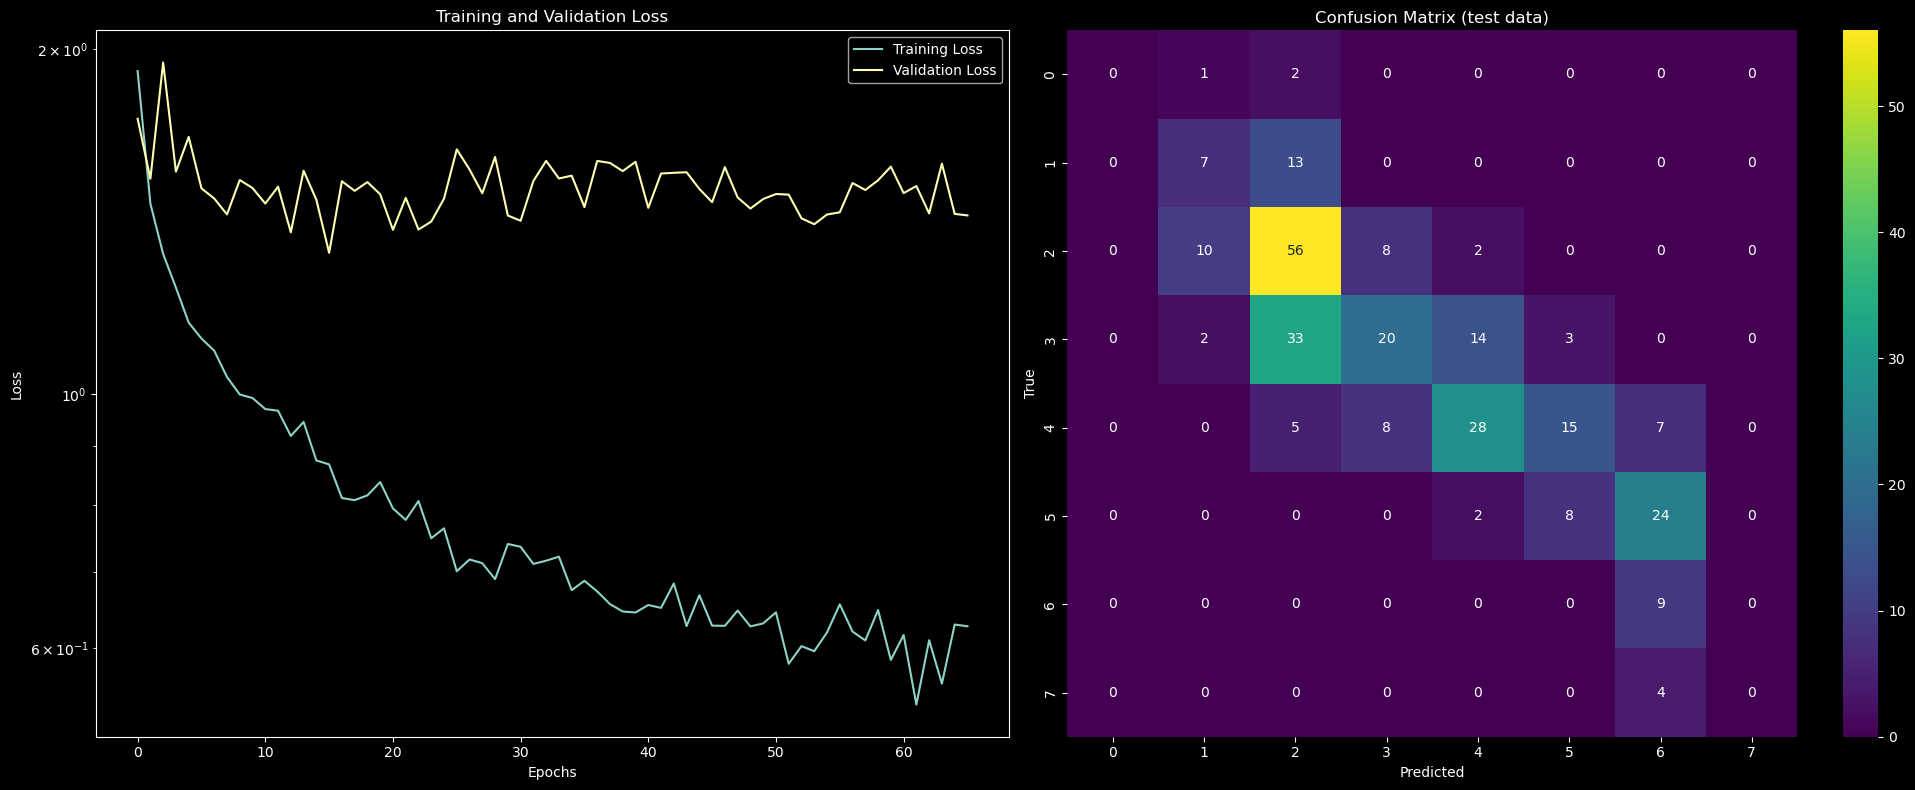

Accuracy:
  Train: 0.6102
  Test:  0.4555


In [32]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Get predictions
y_train_pred = model.predict(X_train).argmax(axis=1)
y_test_pred  = model.predict(X_test).argmax(axis=1)

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Left subplot: Training and Validation Loss
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_yscale('log')
axes[0].set_title('Training and Validation Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Right subplot: Confusion matrix (test data)
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', ax=axes[1])
axes[1].set_title('Confusion Matrix (test data)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)

print("Accuracy:")
print(f"  Train: {acc_train:.4f}")
print(f"  Test:  {acc_test:.4f}")

### Comparison w/ other models

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Define classification models
models = [
    LogisticRegression(max_iter=1000),
    KNeighborsClassifier(n_neighbors=5, weights='uniform'),
    KNeighborsClassifier(n_neighbors=10, weights='uniform'),
    KNeighborsClassifier(n_neighbors=50, weights='uniform'),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=3),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=10),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=30),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=3),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=10),
]

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []
for m in models:
    m.fit(X_train, y_train)
    y_train_pred = m.predict(X_train)
    y_test_pred = m.predict(X_test)
    
    results.append({
        'Model': str(m),
        'Train Accuracy': accuracy_score(y_train, y_train_pred),
        'Test Accuracy': accuracy_score(y_test, y_test_pred),
        'Train Precision': precision_score(y_train, y_train_pred, average='weighted', zero_division=0),
        'Test Precision': precision_score(y_test, y_test_pred, average='weighted', zero_division=0),
        'Train Recall': recall_score(y_train, y_train_pred, average='weighted', zero_division=0),
        'Test Recall': recall_score(y_test, y_test_pred, average='weighted', zero_division=0),
        'Train F1': f1_score(y_train, y_train_pred, average='weighted', zero_division=0),
        'Test F1': f1_score(y_test, y_test_pred, average='weighted', zero_division=0),
    })
# end

In [35]:
comparison_df = (pd.DataFrame(results)
                 .set_index('Model')
                 .sort_values(by='Test F1', ascending=False)
)
comparison_df

,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
Model,,,,,,,,
GradientBoostingClassifier(max_leaf_nodes=3),0.788582,0.587189,0.795862,0.581571,0.788582,0.587189,0.786437,0.578353
KNeighborsClassifier(n_neighbors=10),0.628011,0.590747,0.623666,0.581420,0.628011,0.590747,0.609200,0.577103
RandomForestClassifier(max_leaf_nodes=30),0.672614,0.608541,0.699835,0.559319,0.672614,0.608541,0.640174,0.575310
GradientBoostingClassifier(max_leaf_nodes=10),0.954505,0.576512,0.955283,0.573723,0.954505,0.576512,0.954420,0.571708
KNeighborsClassifier(),0.664585,0.580071,0.665295,0.575679,0.664585,0.580071,0.656520,0.569294
LogisticRegression(max_iter=1000),0.756467,0.569395,0.760022,0.567014,0.756467,0.569395,0.754546,0.563104
RandomForestClassifier(max_leaf_nodes=10),0.587868,0.569395,0.513667,0.500570,0.587868,0.569395,0.538102,0.523492
KNeighborsClassifier(n_neighbors=50),0.537913,0.523132,0.509656,0.460016,0.537913,0.523132,0.492496,0.479008
RandomForestClassifier(max_leaf_nodes=3),0.474576,0.462633,0.356280,0.342677,0.474576,0.462633,0.370673,0.356160


### Perform cross validation

In [36]:
from keras.models import Sequential
from keras.layers import *
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_model( X_train, n_classes, initial_learning_rate, dropout_rate ):

    # Create model
    model = Sequential([
        Input(shape=X_train.shape[1:]),
        
        Dense(20),
        BatchNormalization(),
        Activation('relu'),
        Dropout(dropout_rate),

        Dense(20),
        BatchNormalization(),
        Activation('relu'),
        Dropout(dropout_rate),
        
        Dense(10, activation='relu'),
        
        Dense(n_classes, activation='softmax'),
    ])
    
    # Define the optimizer with a custom learning rate
    optimizer = Adam(
        learning_rate=initial_learning_rate,
    )
    
    # Compile model
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model
# end

In [37]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

epochs                = 1000
batch_size            = 256
dropout_rate          = 0.25
initial_learning_rate = 0.01

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True)

results = []

fold = 1
for train_index, test_index in kf.split(X):
    print(f"Fold {fold}/{n_splits}")
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Build a fresh model (which resets optimizer state)
    model = build_model(
        X_train,
        n_classes,
        initial_learning_rate,
        dropout_rate
    )

    # Early stopping callback
    early_stopping = EarlyStopping(
        monitor='val_loss',  # Monitor validation loss
        patience=100,          # Stop after 5 epochs without improvement
        restore_best_weights=True  # Restore the best weights after stopping
    )
    
    # Train the model
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test, y_test),
        verbose=0,
        callbacks=[early_stopping]
    )
    
    # Evaluate on training data
    y_train_pred = model.predict(X_train, verbose=0).argmax(axis=1)
    
    # Evaluate on test data
    y_test_pred = model.predict(X_test, verbose=0).argmax(axis=1)
    
    fold_results = {
        'Train Accuracy': accuracy_score(y_train, y_train_pred),
        'Test Accuracy': accuracy_score(y_test, y_test_pred),
        'Train Precision': precision_score(y_train, y_train_pred, average='weighted', zero_division=0),
        'Test Precision': precision_score(y_test, y_test_pred, average='weighted', zero_division=0),
        'Train Recall': recall_score(y_train, y_train_pred, average='weighted', zero_division=0),
        'Test Recall': recall_score(y_test, y_test_pred, average='weighted', zero_division=0),
        'Train F1': f1_score(y_train, y_train_pred, average='weighted', zero_division=0),
        'Test F1': f1_score(y_test, y_test_pred, average='weighted', zero_division=0),
    }
    
    print("Accuracy:")
    print(f"  Train: {fold_results['Train Accuracy']:.4f}")
    print(f"  Test:  {fold_results['Test Accuracy']:.4f}")
    print()
    
    results.append(fold_results)
    
    fold += 1
# end

Fold 1/5
Accuracy:
  Train: 0.7288
  Test:  0.6263

Fold 2/5
Accuracy:
  Train: 0.7583
  Test:  0.5623

Fold 3/5
Accuracy:
  Train: 0.7611
  Test:  0.5714

Fold 4/5
Accuracy:
  Train: 0.7718
  Test:  0.6143

Fold 5/5
Accuracy:
  Train: 0.6863
  Test:  0.5143



In [38]:
results_df = pd.DataFrame(results)

results_df.describe()

,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,0.741263,0.577722,0.732114,0.559310,0.741263,0.577722,0.723484,0.558154
std,0.034631,0.044728,0.045908,0.056501,0.034631,0.044728,0.045727,0.050061
min,0.686275,0.514286,0.654238,0.469807,0.686275,0.514286,0.654644,0.479562
25%,0.728814,0.562278,0.737919,0.555302,0.728814,0.562278,0.700550,0.549248
50%,0.758252,0.571429,0.738685,0.555833,0.758252,0.571429,0.744349,0.559524
75%,0.761141,0.614286,0.756399,0.604127,0.761141,0.614286,0.750298,0.595848
max,0.771836,0.626335,0.773330,0.611483,0.771836,0.626335,0.767579,0.606586
